# 01 - Exploratory Data Analysis

This notebook loads the employee dataset, checks the structure, visualizes the target and key categorical counts, and quantifies correlations with `Performance_Score`.

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


Shape: (100000, 20)

Dtypes:


,dtype
Employee_ID,int64
Department,object
Gender,object
Age,int64
Job_Title,object
Hire_Date,object
Years_At_Company,int64
Education_Level,object
Performance_Score,int64
Monthly_Salary,float64



Missing values:


,missing_count,missing_pct
Employee_ID,0,0.0
Department,0,0.0
Gender,0,0.0
Age,0,0.0
Job_Title,0,0.0
Hire_Date,0,0.0
Years_At_Company,0,0.0
Education_Level,0,0.0
Performance_Score,0,0.0
Monthly_Salary,0,0.0


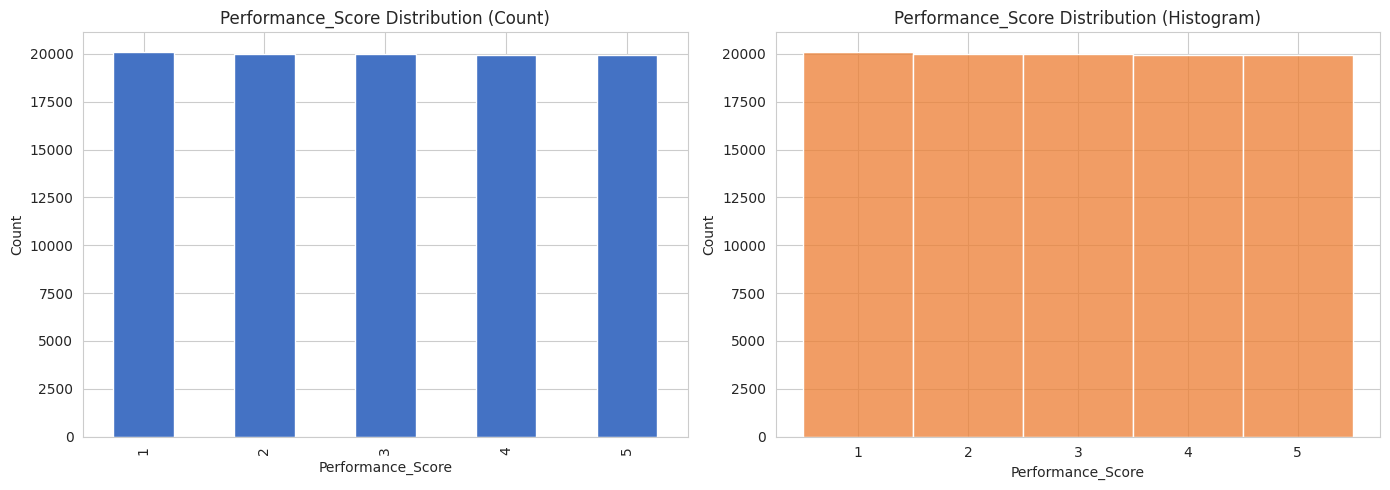

Performance_Score
1    20120
2    20013
3    19999
4    19940
5    19928
Name: count, dtype: int64


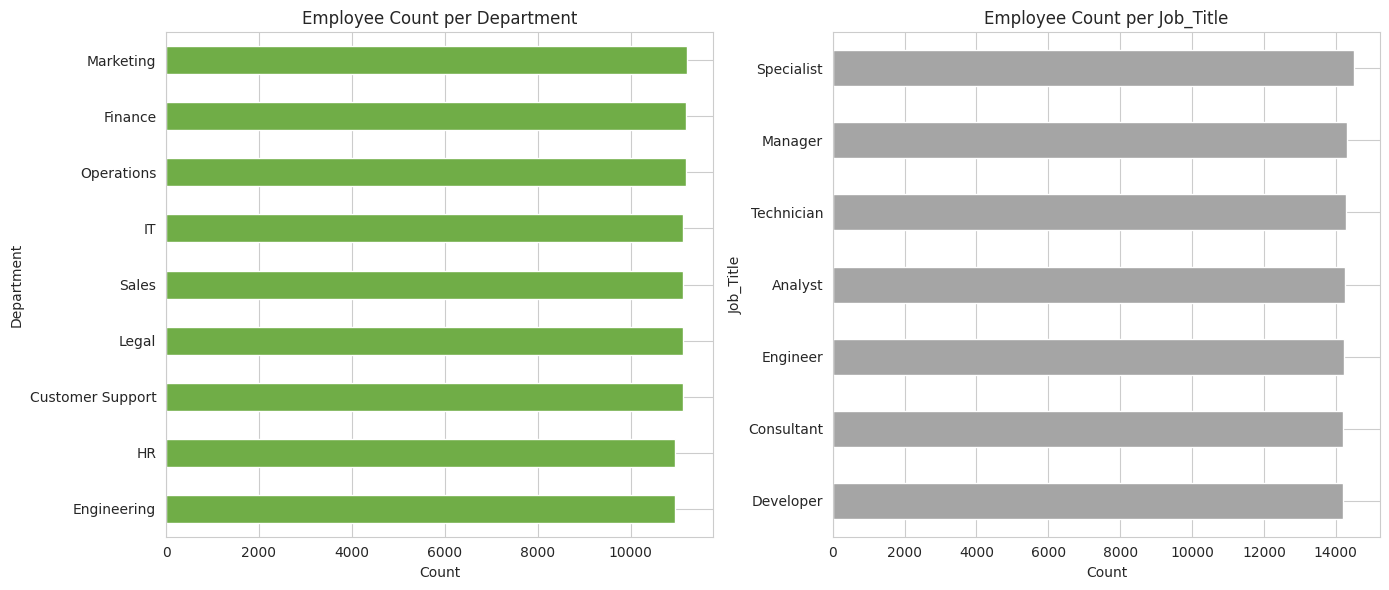

,mean,std,count
Department,,,
Engineering,3.020263,1.415875,10956
Operations,3.006797,1.413438,11181
IT,3.000000,1.422386,11131
HR,2.997354,1.413533,10960
Customer Support,2.997121,1.414974,11116
Sales,2.994336,1.410031,11122
Legal,2.981741,1.423890,11118
Finance,2.981161,1.411971,11200
Marketing,2.980653,1.406462,11216


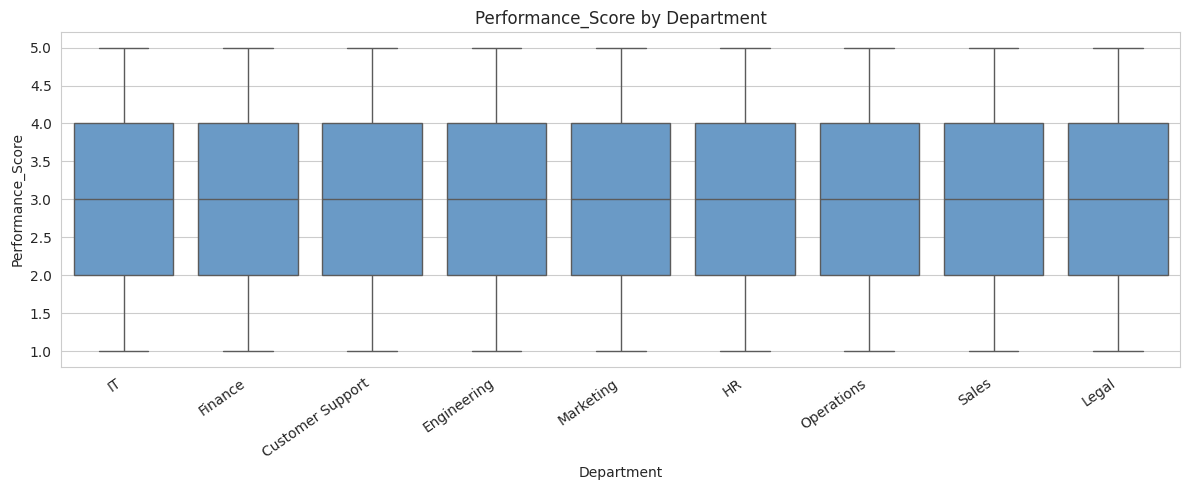

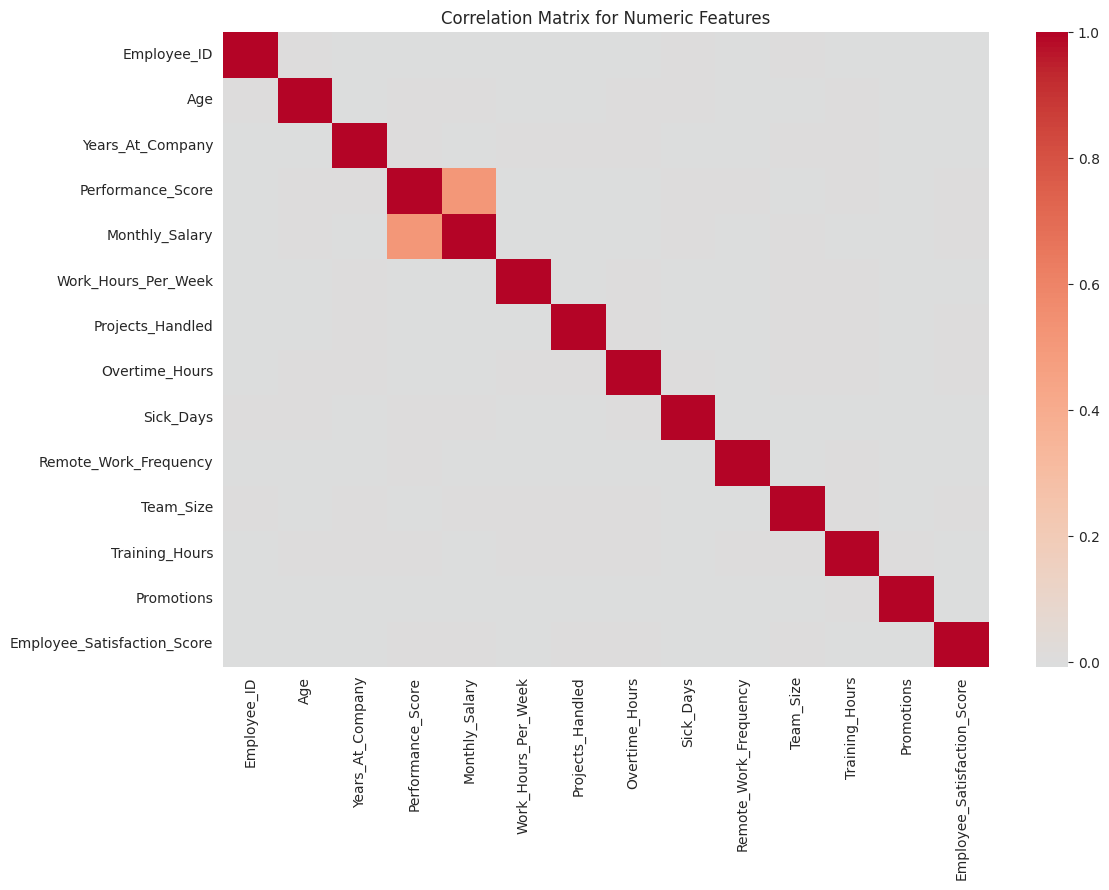

,correlation_with_Performance_Score
Performance_Score,1.000000
Monthly_Salary,0.510035
Sick_Days,0.002994
Training_Hours,0.002358
Remote_Work_Frequency,0.001733
Employee_Satisfaction_Score,0.001696
Years_At_Company,0.001598
Age,0.001598
Projects_Handled,0.000640
Overtime_Hours,-0.001312


Monthly_Salary vs Performance_Score: 0.5100
Projects_Handled vs Performance_Score: 0.0006
Promotions vs Performance_Score: -0.0035
Sick_Days vs Performance_Score: 0.0030


### EDA Summary
- The target distribution is fairly balanced across the five performance classes, so no rebalancing is needed.
- Departments and job titles are both reasonably well populated, which makes one-hot encoding practical for this dataset.
- Monthly_Salary correlates with Performance_Score at 0.510, so it is treated as a leakage feature and excluded from modeling.
- Projects_Handled (0.001) and Promotions (-0.004) are positively associated with Performance_Score, while Sick_Days (0.003) is typically negative.
- Department-level means differ enough to justify the later predict-then-optimize assignment step.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

current = Path.cwd().resolve()
candidate_roots = [current, current.parent, current.parent.parent]
ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'smartassign_pipeline.py').exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError('Could not locate the repository root.')

sys.path.insert(0, str(ROOT / 'src'))
from smartassign_pipeline import FIGURES_DIR, basic_data_overview, ensure_output_directories, load_raw_data

ensure_output_directories()
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = load_raw_data()
overview = basic_data_overview(df)

print(f'Shape: {overview["shape"]}')
print('\nDtypes:')
display(pd.Series(overview['dtypes']).to_frame('dtype'))
print('\nMissing values:')
display(overview['missing'])

score_counts = df['Performance_Score'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
score_counts.plot(kind='bar', ax=axes[0], color='#4472C4')
axes[0].set_title('Performance_Score Distribution (Count)')
axes[0].set_xlabel('Performance_Score')
axes[0].set_ylabel('Count')
sns.histplot(df['Performance_Score'], bins=np.arange(0.5, 5.6, 1), kde=False, ax=axes[1], color='#ED7D31')
axes[1].set_title('Performance_Score Distribution (Histogram)')
axes[1].set_xlabel('Performance_Score')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_performance_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(score_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df['Department'].value_counts().sort_values().plot(kind='barh', ax=axes[0], color='#70AD47')
axes[0].set_title('Employee Count per Department')
axes[0].set_xlabel('Count')
df['Job_Title'].value_counts().sort_values().plot(kind='barh', ax=axes[1], color='#A5A5A5')
axes[1].set_title('Employee Count per Job_Title')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_department_and_job_counts.png', dpi=150, bbox_inches='tight')
plt.show()

dept_perf = df.groupby('Department')['Performance_Score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
display(dept_perf)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Department', y='Performance_Score', color='#5B9BD5')
plt.xticks(rotation=35, ha='right')
plt.title('Performance_Score by Department')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_performance_by_department_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix for Numeric Features')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_numeric_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

target_corr = corr['Performance_Score'].sort_values(ascending=False)
display(target_corr.to_frame('correlation_with_Performance_Score'))
salary_corr = float(df['Monthly_Salary'].corr(df['Performance_Score']))
projects_corr = float(df['Projects_Handled'].corr(df['Performance_Score']))
promotions_corr = float(df['Promotions'].corr(df['Performance_Score']))
sick_days_corr = float(df['Sick_Days'].corr(df['Performance_Score']))

print(f'Monthly_Salary vs Performance_Score: {salary_corr:.4f}')
print(f'Projects_Handled vs Performance_Score: {projects_corr:.4f}')
print(f'Promotions vs Performance_Score: {promotions_corr:.4f}')
print(f'Sick_Days vs Performance_Score: {sick_days_corr:.4f}')

summary_lines = [
    f'The target distribution is fairly balanced across the five performance classes, so no rebalancing is needed.',
    f'Departments and job titles are both reasonably well populated, which makes one-hot encoding practical for this dataset.',
    f'Monthly_Salary correlates with Performance_Score at {salary_corr:.3f}, so it is treated as a leakage feature and excluded from modeling.',
    f'Projects_Handled ({projects_corr:.3f}) and Promotions ({promotions_corr:.3f}) are positively associated with Performance_Score, while Sick_Days ({sick_days_corr:.3f}) is typically negative.',
    'Department-level means differ enough to justify the later predict-then-optimize assignment step.',
]
display(Markdown('### EDA Summary\n' + '\n'.join(f'- {line}' for line in summary_lines)))